# SABER Aggregate Agent Architecture Analysis (Cross-Domain)

## Purpose

This notebook aggregates **agent architecture comparison** analysis across **all SABER benchmark domains**. It normalizes scores and metrics so that domains with many samples don't dominate the aggregate.

The primary comparison axis is **agent architecture** (React, GH Copilot, Claude Code) rather than model identity. Currently configured for **Claude Sonnet 4.6** across all three agents.

### Normalization Method

Same as the model-level aggregate: for each metric, compute per-domain means first, then average with equal weight per domain.

$$\text{Aggregate Score}(a) = \frac{1}{|\mathcal{D}|} \sum_{d \in \mathcal{D}} \overline{\text{score}}(a, d)$$

### Analyses

| # | Analysis | What it shows |
|---|----------|---------------|
| 1 | Normalized Overall Reward | Domain-weighted mean score per agent config |
| 2 | Per-Domain Score Breakdown | Agent scores across all domains |
| 3 | Normalized Cost Analysis | Per-sample cost, Pareto chart |
| 4 | Normalized Cost Efficiency | Reward per dollar |
| 5 | Sub-Task Breakdown | Submission/Checkpoints/Aggregate per agent |
| 6 | Agent Trajectory Efficiency | Tool calls, steps, time per agent |
| 7 | Cross-Domain Ranking Consistency | Do agents rank the same across domains? |
| 8 | Cross-Domain Radar Chart | Per-domain strength per agent |

### Configuring Domains

Edit the `DOMAINS` dict in the Configuration cell to add/remove domains.
Edit `AGENT_EVAL_LOGS` within each domain to specify agent × model eval files.

<a id="configuration"></a>
## Configuration

Edit the cell below to configure which **domains** and **agent architectures** are included.

### Adding an agent architecture

1. Add the agent to each domain's `agent_eval_logs` dict
2. Add a color in `AGENT_COLORS`
3. Ensure the corresponding `.eval` files exist

### Adding a domain

Add a new entry to `DOMAINS` with the domain's agent eval log mappings.

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — Aggregate Agent Architecture Analysis (Cross-Domain)
# ══════════════════════════════════════════════════════════════════════════════
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

NOTEBOOK_DIR = Path('.').resolve()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from saber_analysis.data_loader import load_eval_logs, load_trajectory_data, ensure_eval_files
from saber_analysis.cost import extract_cost_rows
from saber_analysis.plots import setup_plotting, classify_score_type

setup_plotting()

REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
ARTIFACTS_DIR = NOTEBOOK_DIR / 'artifacts' / 'aggregate_agent'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# DOMAIN REGISTRY — Each domain specifies its agent × model eval logs
# ══════════════════════════════════════════════════════════════════════════════
DOMAINS = {
    'excytin': {
        'name': 'Excytin',
        'n_samples': 599,
        'agent_eval_logs': {
            'React': {
                'Claude Sonnet 4.6': 'sonnet_4.6_react.eval',
            },
            'GH Copilot': {
                'Claude Sonnet 4.6': 'sonnet_4.6_copilot.eval',
            },
            'Claude Code': {
                'Claude Sonnet 4.6': 'sonnet_4.6_claude_code.eval',
            },
        },
        'group_fn': lambda sid: '_'.join(sid.split('_')[:2]),
    },
    'cti_realm': {
        'name': 'CTI Realm',
        'n_samples': 25,
        'agent_eval_logs': {
            'React': {
                'Claude Sonnet 4.6': 'sonnet_4.6_cti_realm_25.eval',
            },
            'GH Copilot': {
                'Claude Sonnet 4.6': 'sonnet_4.6_copilot.eval',
            },
            'Claude Code': {
                'Claude Sonnet 4.6': 'sonnet_4.6_claude_code.eval',
            },
        },
        'group_fn': lambda sid: sid.split('_')[0],
    },
    'cybench': {
        'name': 'CyBench',
        'n_samples': 1,
        'agent_eval_logs': {
            'React': {
                'Claude Sonnet 4.6': 'sonnet_4.6_react.eval',
            },
            'GH Copilot': {
                'Claude Sonnet 4.6': 'sonnet_4.6_copilot.eval',
            },
            'Claude Code': {
                'Claude Sonnet 4.6': 'sonnet_4.6_claude_code.eval',
            },
        },
        'group_fn': lambda sid: '_'.join(sid.split('_')[:-2]),
    },
}

# ══════════════════════════════════════════════════════════════════════════════
# AGENT & MODEL DISPLAY
# ══════════════════════════════════════════════════════════════════════════════
AGENT_COLORS = {
    'React':       '#2CA02C',
    'GH Copilot':  '#E74C3C',
    'Claude Code': '#3498DB',
}

MODEL_COLORS = {
    'Claude Haiku 4.5':  '#17BECF',
    'Claude Sonnet 4.6': '#F39C12',
    'Claude Opus 4.6':   '#E74C3C',
    'GPT-5.4':           '#2CA02C',
    'GPT-5.4-mini':      '#7B4FBF',
}

DOMAIN_COLORS = {
    'excytin':   '#3498DB',
    'cti_realm': '#E74C3C',
    'cybench':   '#2ECC71',
}

# Discover all agent configs across all domains
_seen = set()
CONFIG_ORDER = []  # display names like "Claude Sonnet 4.6 (React)"
COLORS = {}
AGENT_OF = {}
MODEL_OF = {}
for d_cfg in DOMAINS.values():
    for agent, models in d_cfg['agent_eval_logs'].items():
        for model, filename in models.items():
            display = f'{model} ({agent})'
            if display not in _seen:
                CONFIG_ORDER.append(display)
                _seen.add(display)
                # Color by agent when single model, by model when multi-model
                n_unique_models = len(set(
                    m for dc in DOMAINS.values()
                    for a in dc['agent_eval_logs'].values()
                    for m in a
                ))
                COLORS[display] = (AGENT_COLORS.get(agent, '#888')
                                   if n_unique_models == 1
                                   else MODEL_COLORS.get(model, '#888'))
                AGENT_OF[display] = agent
                MODEL_OF[display] = model

# ══════════════════════════════════════════════════════════════════════════════
# PRICING — $/1M tokens
# ══════════════════════════════════════════════════════════════════════════════
PRICING = {
    'anthropic/claude-haiku-4-5':            {'input': 0.80,  'output': 4.00,  'cache_read': 0.08,   'cache_write': 1.00},
    'anthropic/claude-sonnet-4-6':           {'input': 3.00,  'output': 15.00, 'cache_read': 0.375,  'cache_write': 3.75},
    'anthropic/claude-opus-4-6':             {'input': 15.00, 'output': 75.00, 'cache_read': 1.875,  'cache_write': 18.75},
    'openai/azure/gpt-5.4':                  {'input': 10.00, 'output': 30.00, 'cache_read': 2.50,   'cache_write': 0.0},
    'openai/azure/gpt-5.4-mini-2026-03-17':  {'input': 1.10,  'output': 4.40,  'cache_read': 0.275,  'cache_write': 0.0},
}

print(f'Aggregate Agent Architecture Analysis')
print(f'  Domains: {len(DOMAINS)} — {", ".join(d["name"] for d in DOMAINS.values())}')
print(f'  Agent configs: {len(CONFIG_ORDER)} — {", ".join(CONFIG_ORDER)}')
for slug, d_cfg in DOMAINS.items():
    agents = list(d_cfg['agent_eval_logs'].keys())
    print(f'  {d_cfg["name"]:12s}: {d_cfg["n_samples"]:>4d} samples, agents: {", ".join(agents)}')

Aggregate Agent Architecture Analysis
  Domains: 3 — Excytin, CTI Realm, CyBench
  Agent configs: 3 — Claude Sonnet 4.6 (React), Claude Sonnet 4.6 (GH Copilot), Claude Sonnet 4.6 (Claude Code)
  Excytin     :  599 samples, agents: React, GH Copilot, Claude Code
  CTI Realm   :   25 samples, agents: React, GH Copilot, Claude Code
  CyBench     :    1 samples, agents: React, GH Copilot, Claude Code


## Data Loading

Loads eval data for each domain's agent configurations. For each domain, flattens the `agent_eval_logs` into the standard `{display_name: filename}` format used by the shared data loading functions.

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# DATA LOADING — Load all domains × agent configs
# ══════════════════════════════════════════════════════════════════════════════
from collections import Counter

domain_data = {}

for slug, d_cfg in DOMAINS.items():
    log_dir = str(REPO_ROOT / 'eval_samples' / slug)

    # Flatten agent_eval_logs → {display_name: filename}
    eval_logs = {}
    d_config_order = []
    for agent, models in d_cfg['agent_eval_logs'].items():
        for model, filename in models.items():
            display = f'{model} ({agent})'
            eval_logs[display] = filename
            d_config_order.append(display)

    ensure_eval_files(
        eval_logs, log_dir, slug,
        fallback_dirs=[str(REPO_ROOT / 'latest_experiments' / slug)],
    )

    samples_df, subtasks_df, overall_df, model_overall = load_eval_logs(
        eval_logs, log_dir, d_config_order, group_fn=d_cfg.get('group_fn')
    )

    cost_rows = extract_cost_rows(eval_logs, log_dir, PRICING, d_cfg['n_samples'])
    cost_df = pd.DataFrame(cost_rows).set_index('model').reindex(d_config_order)

    traj_df = load_trajectory_data(eval_logs, log_dir, d_config_order, group_fn=d_cfg.get('group_fn'))
    traj_df['tool_counts'] = traj_df['tool_counts'].apply(
        lambda d: dict(Counter({k.lower(): v for k, v in d.items()}))
    )

    domain_data[slug] = {
        'samples_df': samples_df,
        'subtasks_df': subtasks_df,
        'overall_df': overall_df,
        'model_overall': model_overall,
        'cost_df': cost_df,
        'traj_df': traj_df,
        'config_order': d_config_order,
    }
    print(f'  {d_cfg["name"]:12s}: {len(samples_df)} samples, {len(subtasks_df)} subtasks, {len(traj_df)} trajectories')

# ══════════════════════════════════════════════════════════════════════════════
# BUILD CROSS-DOMAIN AGGREGATE TABLES
# ══════════════════════════════════════════════════════════════════════════════
domain_slugs = list(DOMAINS.keys())
domain_names = {s: DOMAINS[s]['name'] for s in domain_slugs}

# Per-domain mean score per config
score_by_domain = pd.DataFrame(index=CONFIG_ORDER, columns=domain_slugs, dtype=float)
for slug, dd in domain_data.items():
    for cfg, stats in dd['model_overall'].items():
        if cfg in score_by_domain.index:
            score_by_domain.loc[cfg, slug] = stats['mean']

agg_scores = score_by_domain.mean(axis=1)
agg_stderr = score_by_domain.sem(axis=1)
domain_coverage = score_by_domain.notna().sum(axis=1)

# Cost per sample
cost_per_sample_by_domain = pd.DataFrame(index=CONFIG_ORDER, columns=domain_slugs, dtype=float)
for slug, dd in domain_data.items():
    for cfg in dd['cost_df'].index:
        if cfg in cost_per_sample_by_domain.index:
            cost_per_sample_by_domain.loc[cfg, slug] = dd['cost_df'].loc[cfg, 'cost_per_sample']
agg_cost_per_sample = cost_per_sample_by_domain.mean(axis=1)

# Trajectory stats
traj_by_domain = {}
for metric in ['n_tool_calls', 'n_steps', 'total_time']:
    tdf = pd.DataFrame(index=CONFIG_ORDER, columns=domain_slugs, dtype=float)
    for slug, dd in domain_data.items():
        for cfg in dd['config_order']:
            mdf = dd['traj_df'][dd['traj_df']['model'] == cfg]
            if len(mdf) > 0 and cfg in tdf.index:
                tdf.loc[cfg, slug] = mdf[metric].mean()
    traj_by_domain[metric] = tdf

agg_tool_calls = traj_by_domain['n_tool_calls'].mean(axis=1)
agg_steps = traj_by_domain['n_steps'].mean(axis=1)
agg_time = traj_by_domain['total_time'].mean(axis=1)

print(f'\n═══ Per-Domain Scores ═══')
display_scores = score_by_domain.copy()
display_scores.columns = [domain_names[s] for s in domain_slugs]
display_scores['Aggregate'] = agg_scores
print(display_scores.round(4).to_string())

✓ All 3 eval files found locally in /home/amudgerikar/repos/oss_saber/eval_samples/excytin
  Excytin     : 1797 samples, 7791 subtasks, 1797 trajectories
✓ All 3 eval files found locally in /home/amudgerikar/repos/oss_saber/eval_samples/cti_realm
  CTI Realm   : 75 samples, 450 subtasks, 75 trajectories
✓ All 3 eval files found locally in /home/amudgerikar/repos/oss_saber/eval_samples/cybench
  CyBench     : 3 samples, 24 subtasks, 3 trajectories

═══ Per-Domain Scores ═══
                                 Excytin  CTI Realm  CyBench  Aggregate
Claude Sonnet 4.6 (React)         0.8567     0.5467   1.0000     0.8011
Claude Sonnet 4.6 (GH Copilot)    0.7906     0.1544   1.0000     0.6484
Claude Sonnet 4.6 (Claude Code)   0.8173     0.1737   0.3333     0.4415


---

## 1. Normalized Overall Reward per Agent Config

Domain-weighted mean `saber_overall` per agent architecture. Each domain contributes equally.

**Key findings:**
- **React leads decisively** at **0.801** aggregate reward, followed by GH Copilot (0.648) and Claude Code (0.441).
- React's advantage over Copilot (+0.153) is smaller than Copilot's advantage over Claude Code (+0.207), suggesting a clear tier separation.
- **Large error bars** (cross-domain std) reflect high domain variability — all configs score well on Excytin but diverge sharply on CTI Realm and CyBench. React's stderr (±0.134) is the tightest, indicating the most consistent cross-domain performance.

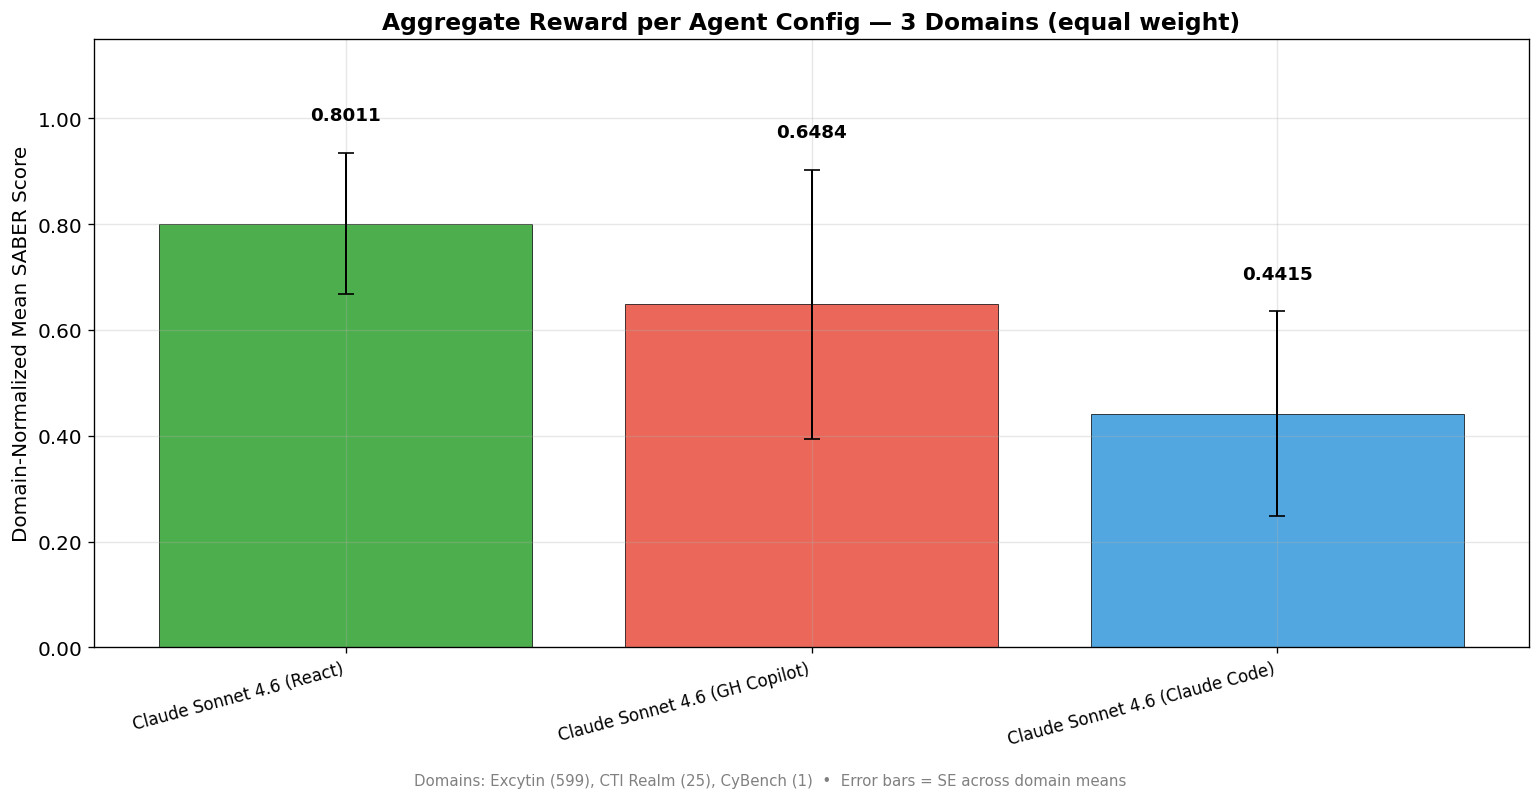

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 1: Normalized Overall Reward per Agent Config
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6.5))

x = np.arange(len(CONFIG_ORDER))
colors = [COLORS.get(c, '#888888') for c in CONFIG_ORDER]
means = [agg_scores[c] for c in CONFIG_ORDER]
stderrs = [agg_stderr[c] if not np.isnan(agg_stderr[c]) else 0 for c in CONFIG_ORDER]

bars = ax.bar(x, means, color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)
ax.errorbar(x, means, yerr=stderrs, fmt='none', ecolor='black', capsize=5, linewidth=1.2)

for i, c in enumerate(CONFIG_ORDER):
    cov = int(domain_coverage[c])
    n_domains = len(DOMAINS)
    cov_label = f'({cov}/{n_domains} domains)' if cov < n_domains else ''
    ax.text(i, means[i] + stderrs[i] + 0.015, f'{means[i]:.4f}\n{cov_label}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(CONFIG_ORDER, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Domain-Normalized Mean SABER Score')
ax.set_title(f'Aggregate Reward per Agent Config — {len(DOMAINS)} Domains (equal weight)',
             fontweight='bold')
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

domain_desc = ', '.join(f'{DOMAINS[s]["name"]} ({DOMAINS[s]["n_samples"]})' for s in domain_slugs)
fig.text(0.5, -0.02, f'Domains: {domain_desc}  •  Error bars = SE across domain means',
         ha='center', fontsize=9, fontstyle='italic', color='gray')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'aggregate_overall_reward.png', bbox_inches='tight')
plt.show()

---

## 2. Per-Domain Score Breakdown

Agent config scores across each domain (grouped bar + heatmap).

**Key findings:**
- **Excytin** is the easiest domain — all three configs score 0.79–0.86, with only 0.07 separating first (React, 0.857) from last (Copilot, 0.791).
- **CTI Realm is the primary differentiator.** React (0.547) more than triples Copilot (0.154) and Claude Code (0.174). This domain drives most of the aggregate gap.
- **CyBench** (n=1 sample): React and Copilot both achieve a perfect 1.000, while Claude Code drops to 0.333. The single-sample size means this should be interpreted cautiously, but it still contributes to the equal-weight aggregate.
- The heatmap reveals that Copilot and Claude Code have similar difficulty profiles (low on CTI Realm) but diverge on CyBench where Copilot succeeds and Claude Code does not.

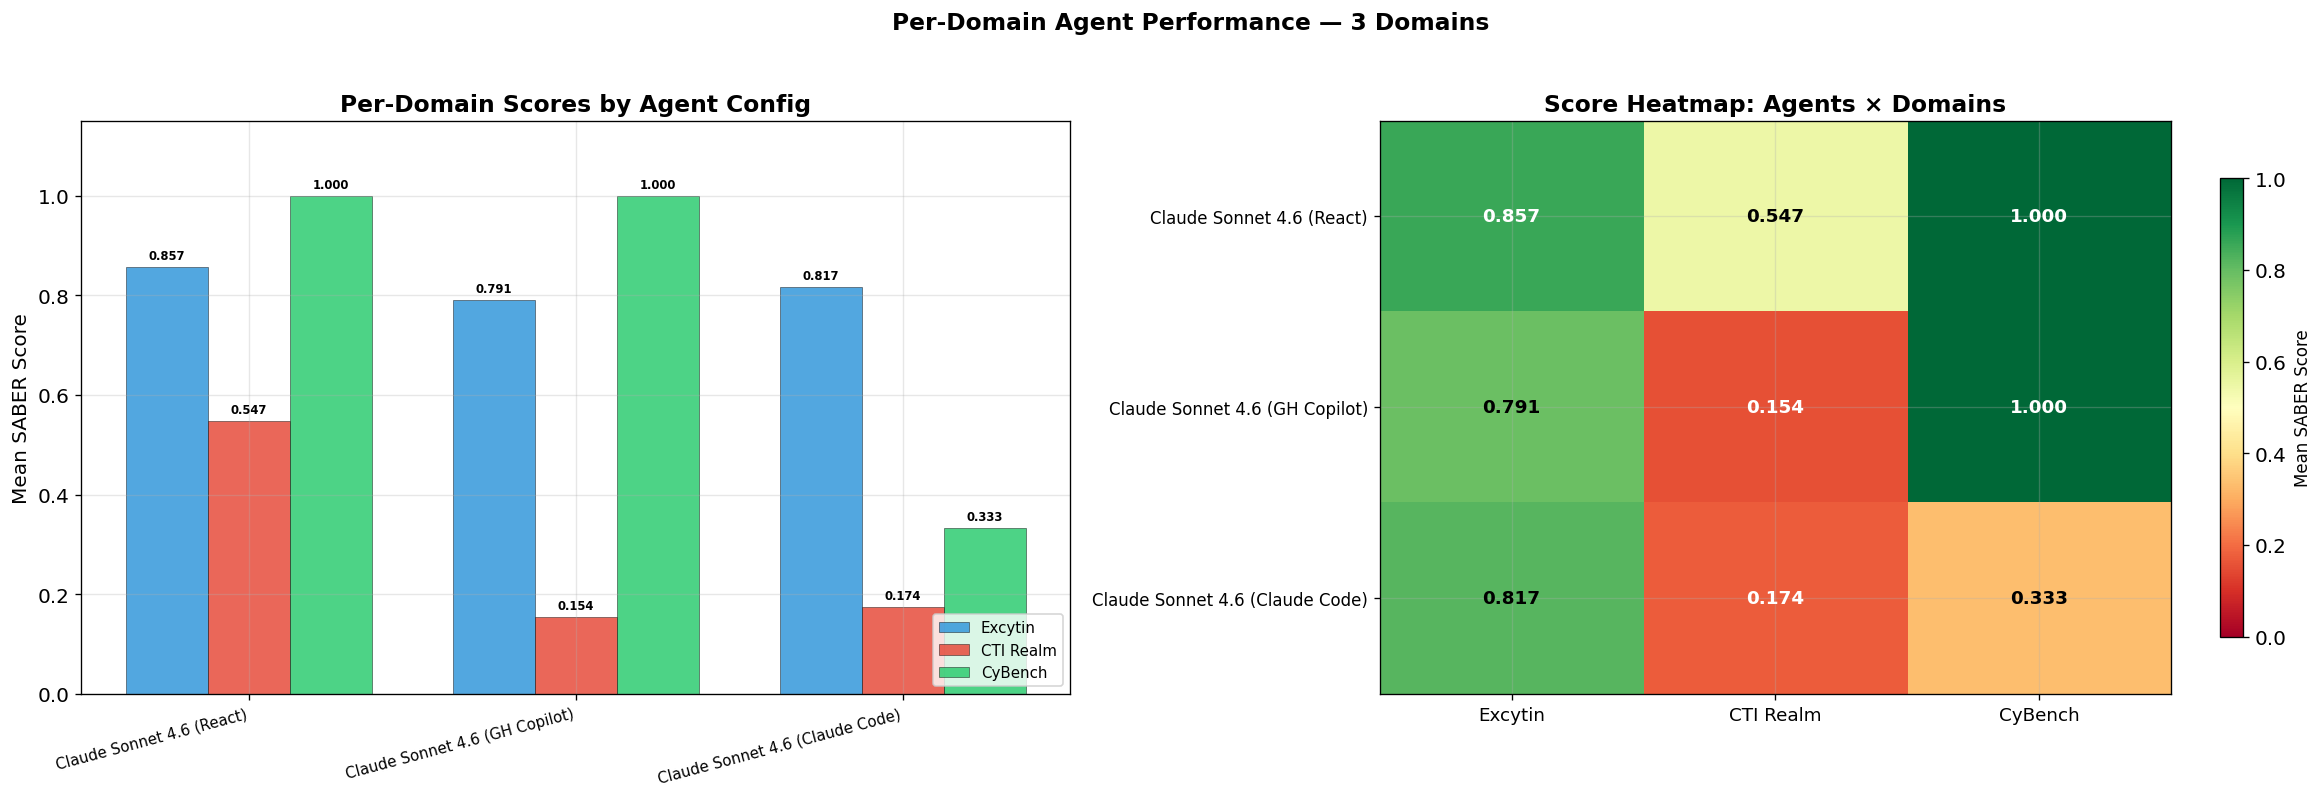

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 2: Per-Domain Score Breakdown
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(20, 6.5))

# Panel 1: Grouped bar
ax = axes[0]
n_domains = len(domain_slugs)
bar_width = min(0.25, 0.8 / n_domains)
x = np.arange(len(CONFIG_ORDER))

for j, slug in enumerate(domain_slugs):
    offset = (j - n_domains/2 + 0.5) * bar_width
    vals = [score_by_domain.loc[c, slug] if not pd.isna(score_by_domain.loc[c, slug]) else 0
            for c in CONFIG_ORDER]
    ax.bar(x + offset, vals, bar_width, color=DOMAIN_COLORS.get(slug, '#888'),
           edgecolor='black', linewidth=0.3, alpha=0.85, label=DOMAINS[slug]['name'])
    for i, v in enumerate(vals):
        if v > 0:
            ax.text(x[i] + offset, v + 0.01, f'{v:.3f}', ha='center', va='bottom',
                    fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(CONFIG_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Mean SABER Score')
ax.set_title('Per-Domain Scores by Agent Config', fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=9, loc='lower right')

# Panel 2: Heatmap
ax = axes[1]
hm_data = score_by_domain.copy()
hm_data.columns = [domain_names[s] for s in domain_slugs]
hm_arr = hm_data.values.astype(float)

im = ax.imshow(hm_arr, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
for i in range(len(CONFIG_ORDER)):
    for j in range(n_domains):
        val = hm_arr[i, j]
        if not np.isnan(val):
            tc = 'white' if val < 0.3 or val > 0.85 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=11, fontweight='bold', color=tc)
        else:
            ax.text(j, i, 'N/A', ha='center', va='center', fontsize=10, color='gray', fontstyle='italic')

ax.set_xticks(range(n_domains))
ax.set_xticklabels(hm_data.columns, fontsize=11)
ax.set_yticks(range(len(CONFIG_ORDER)))
ax.set_yticklabels(CONFIG_ORDER, fontsize=10)
ax.set_title('Score Heatmap: Agents × Domains', fontweight='bold')
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Mean SABER Score', fontsize=10)

fig.suptitle(f'Per-Domain Agent Performance — {len(DOMAINS)} Domains', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'per_domain_breakdown.png', bbox_inches='tight')
plt.show()

---

## 3. Normalized Cost Analysis

Per-sample cost averaged across domains + Pareto chart.

**Key findings:**
- **React is the cheapest** at **\$0.251/sample**, followed by Copilot (\$0.317) and Claude Code (\$0.390).
- React dominates the Pareto frontier — highest score *and* lowest cost. No other config offers a favorable trade-off.
- Cost gap between cheapest and most expensive is 1.55×, while the performance gap is 1.82×, meaning the more expensive configs offer *less* value per dollar (see Exp 4).
- **Per-domain cost breakdown:** React is cheapest on Excytin (\$0.201) and CyBench (\$0.192) but mid-range on CTI Realm (\$0.360). Copilot is cheapest on Excytin (\$0.158) but most expensive on CyBench (\$0.487).

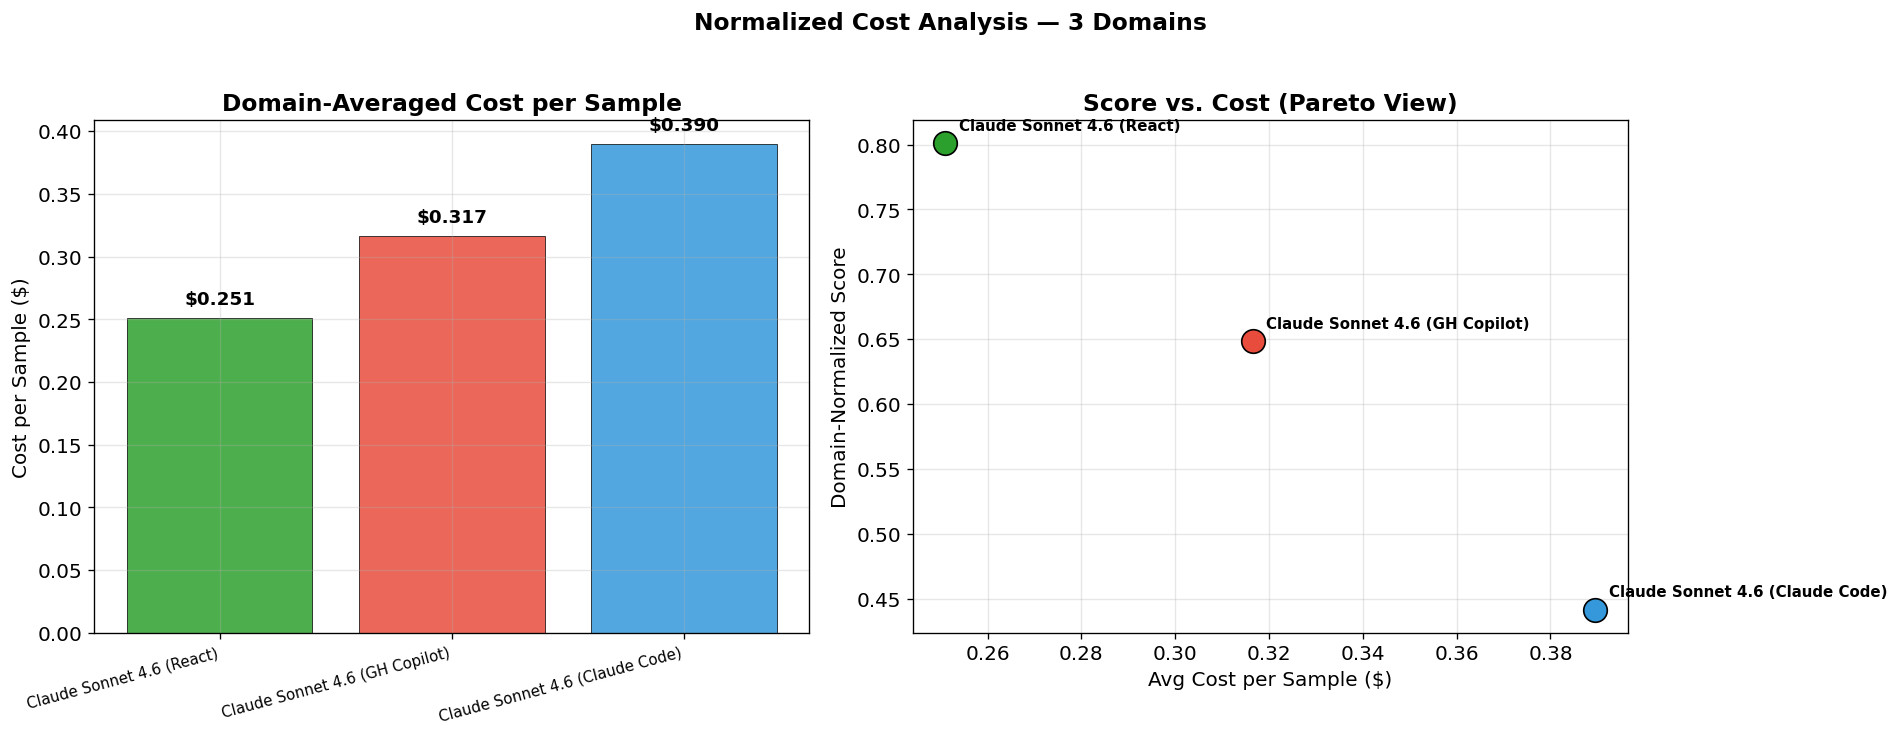

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 3: Normalized Cost Analysis
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(CONFIG_ORDER))
colors = [COLORS.get(c, '#888888') for c in CONFIG_ORDER]

# Panel 1: Cost per sample
ax = axes[0]
cps_vals = [agg_cost_per_sample[c] if not np.isnan(agg_cost_per_sample[c]) else 0 for c in CONFIG_ORDER]
ax.bar(x, cps_vals, color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)
for i, v in enumerate(cps_vals):
    ax.text(i, v + max(cps_vals)*0.02, f'${v:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(CONFIG_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Cost per Sample ($)')
ax.set_title('Domain-Averaged Cost per Sample', fontweight='bold')

# Panel 2: Pareto
ax = axes[1]
for c in CONFIG_ORDER:
    s = agg_scores[c]
    cost = agg_cost_per_sample[c]
    if np.isnan(s) or np.isnan(cost):
        continue
    ax.scatter(cost, s, s=200, color=COLORS.get(c, '#888'), edgecolor='black', linewidth=1, zorder=5)
    ax.annotate(c, (cost, s), textcoords='offset points', xytext=(8, 8), fontsize=9, fontweight='bold')
ax.set_xlabel('Avg Cost per Sample ($)')
ax.set_ylabel('Domain-Normalized Score')
ax.set_title('Score vs. Cost (Pareto View)', fontweight='bold')

fig.suptitle(f'Normalized Cost Analysis — {len(DOMAINS)} Domains', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'aggregate_cost_analysis.png', bbox_inches='tight')
plt.show()

---

## 4. Normalized Cost Efficiency: Reward per Dollar

**Key findings:**
- **React delivers 3.19 reward/$** — nearly **3× more efficient** than Claude Code (1.13 reward/$) and 1.56× more than Copilot (2.05 reward/$).
- The efficiency gap amplifies the raw score differences: React is 1.24× the score of Copilot but 1.56× the efficiency, because React is both better *and* cheaper.
- Claude Code occupies the worst position on both axes — lowest score and highest cost — making it the least efficient architecture across all domains.

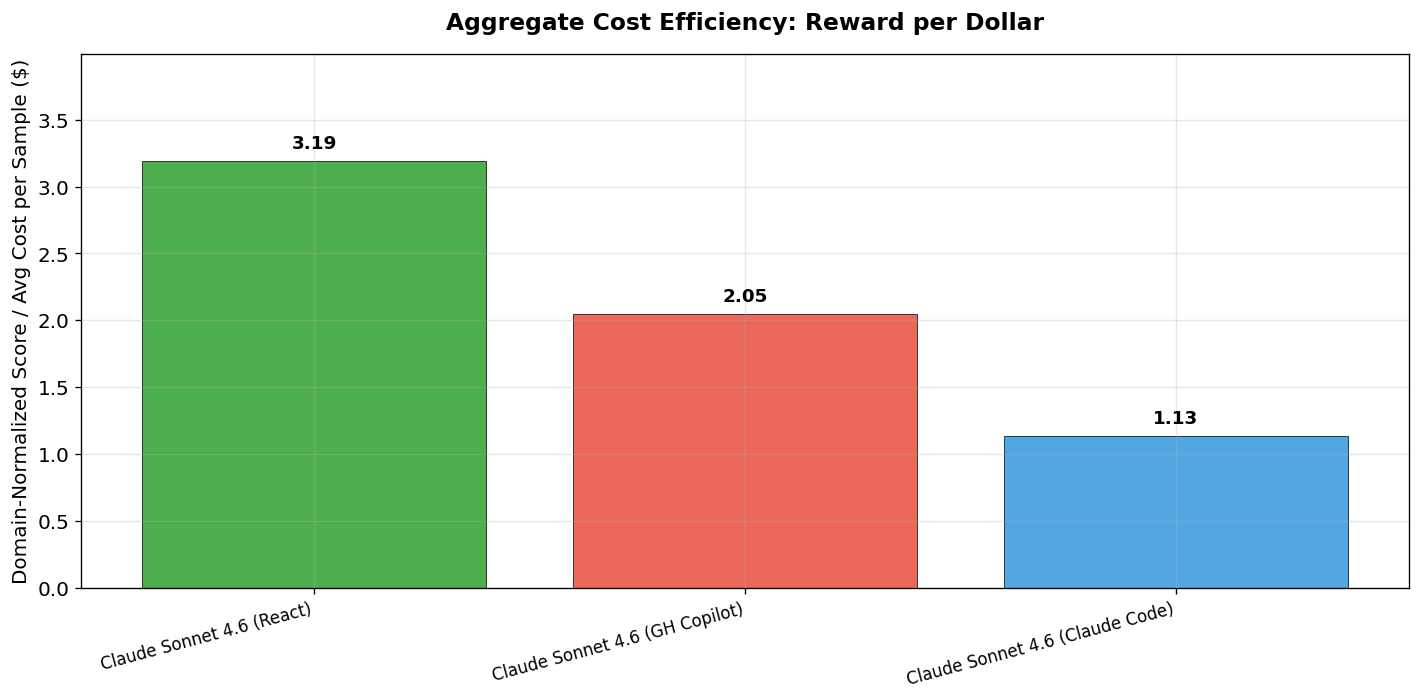

═══ Cost Efficiency Summary ═══
Config                               Agg Score Avg $/sample    Score/$  Domains
────────────────────────────────────────────────────────────────────────────────
Claude Sonnet 4.6 (React)               0.8011 $     0.2510       3.19        3
Claude Sonnet 4.6 (GH Copilot)          0.6484 $     0.3165       2.05        3
Claude Sonnet 4.6 (Claude Code)         0.4415 $     0.3895       1.13        3


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 4: Normalized Cost Efficiency
# ══════════════════════════════════════════════════════════════════════════════
reward_per_dollar = agg_scores / agg_cost_per_sample

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(CONFIG_ORDER))
rpd_vals = [reward_per_dollar[c] if not np.isnan(reward_per_dollar[c]) else 0 for c in CONFIG_ORDER]

for i, c in enumerate(CONFIG_ORDER):
    ax.bar(i, rpd_vals[i], color=COLORS.get(c, '#888'), edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, rpd_vals[i] + max(v for v in rpd_vals if not np.isnan(v))*0.02,
            f'{rpd_vals[i]:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(CONFIG_ORDER, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Domain-Normalized Score / Avg Cost per Sample ($)')
ax.set_title('Aggregate Cost Efficiency: Reward per Dollar', fontweight='bold', pad=15)
ax.set_ylim(0, max(v for v in rpd_vals if not np.isnan(v)) * 1.25)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'aggregate_cost_efficiency.png', bbox_inches='tight')
plt.show()

print('═══ Cost Efficiency Summary ═══')
print(f'{"Config":35s} {"Agg Score":>10s} {"Avg $/sample":>12s} {"Score/$":>10s} {"Domains":>8s}')
print('─' * 80)
for c in CONFIG_ORDER:
    cov = int(domain_coverage[c])
    print(f'{c:35s} {agg_scores[c]:10.4f} ${agg_cost_per_sample[c]:11.4f} '
          f'{reward_per_dollar[c]:10.2f} {cov:8d}')

---

## 5. Sub-Task Breakdown (Domain-Normalized)

Submission, Checkpoints, and Aggregate scores per agent config, averaged across domains.

**Key findings:**
- **Submission scores:** React (0.852) and Copilot (0.846) are virtually identical — only 0.006 apart. Claude Code (0.348) collapses to less than half, indicating it struggles to produce valid final submissions.
- **Checkpoint scores** are the key differentiator between React and Copilot: React (0.548) leads Copilot (0.380) by +0.169, a 44% improvement. This means React executes intermediate investigation steps more thoroughly.
- Claude Code trails on both sub-task categories but the Submission gap (0.504 below React) is far larger than the Checkpoint gap (0.260), suggesting its primary failure mode is assembling final answers rather than in-progress work.
- The near-parity on Submission between React and Copilot, combined with React's clear Checkpoint lead, suggests React's overall advantage comes from superior step-by-step methodology rather than final-answer formatting.

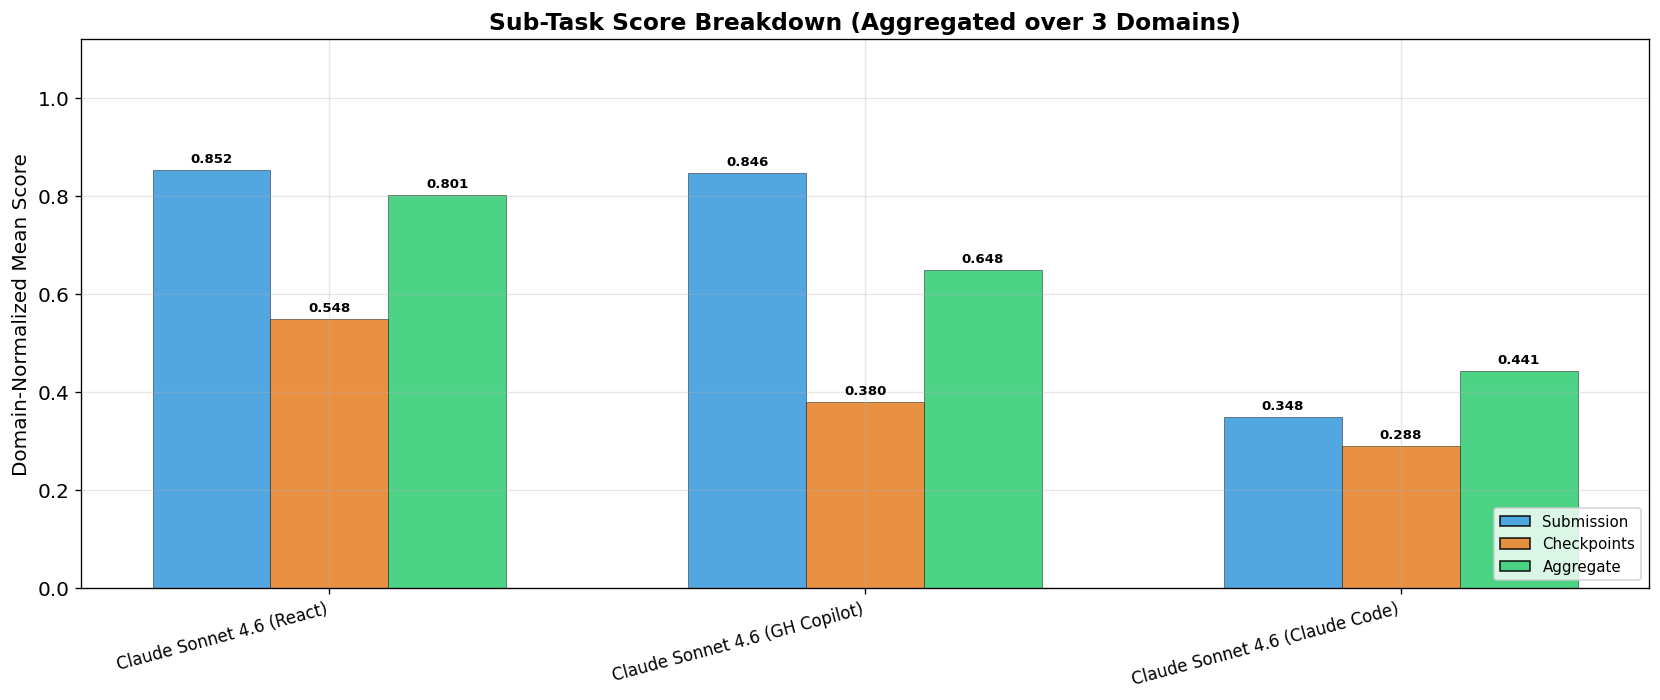

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 5: Sub-Task Breakdown (Domain-Normalized)
# ══════════════════════════════════════════════════════════════════════════════
categories_list = ['Submission', 'Checkpoints', 'Aggregate']

cat_by_domain = {}
for cat in categories_list:
    cdf = pd.DataFrame(index=CONFIG_ORDER, columns=domain_slugs, dtype=float)
    for slug, dd in domain_data.items():
        st_df = dd['subtasks_df'].copy()
        st_df['category'] = st_df['score_type'].apply(classify_score_type)
        cat_data = st_df[st_df['category'] == cat]
        for cfg in dd['config_order']:
            vals = cat_data[cat_data['model'] == cfg]['score']
            if len(vals) > 0 and cfg in cdf.index:
                cdf.loc[cfg, slug] = vals.mean()
    cat_by_domain[cat] = cdf

agg_cat = {cat: cdf.mean(axis=1) for cat, cdf in cat_by_domain.items()}

fig, ax = plt.subplots(figsize=(14, 6))
cat_plot_colors = ['#3498DB', '#E67E22', '#2ECC71']
x = np.arange(len(CONFIG_ORDER))
bar_width = 0.22

for j, (cat, color) in enumerate(zip(categories_list, cat_plot_colors)):
    offset = (j - 1) * bar_width
    vals = [agg_cat[cat][c] if not np.isnan(agg_cat[cat][c]) else 0 for c in CONFIG_ORDER]
    ax.bar(x + offset, vals, bar_width, color=color, edgecolor='black', linewidth=0.3, alpha=0.85)
    for i, v in enumerate(vals):
        if v > 0:
            ax.text(x[i] + offset, v + 0.01, f'{v:.3f}', ha='center', va='bottom',
                    fontsize=8, fontweight='bold')

cat_handles = [mpatches.Patch(facecolor=c, edgecolor='black', alpha=0.85, label=cat)
               for cat, c in zip(categories_list, cat_plot_colors)]
ax.legend(handles=cat_handles, fontsize=9, loc='lower right')
ax.set_xticks(x)
ax.set_xticklabels(CONFIG_ORDER, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Domain-Normalized Mean Score')
ax.set_title(f'Sub-Task Score Breakdown (Aggregated over {len(DOMAINS)} Domains)', fontweight='bold')
ax.set_ylim(0, 1.12)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'aggregate_subtask_breakdown.png', bbox_inches='tight')
plt.show()

---

## 6. Agent Trajectory Efficiency (Domain-Normalized)

Tool calls, steps, and time per sample, averaged across domains.

**Key findings:**
- **Tool calls are nearly identical** across all three configs (~18.7–18.9 calls/sample), suggesting the agent architectures explore a similar depth of tool usage.
- **Time diverges sharply:** React averages **3.3 min/sample**, while Copilot takes 5.0 min and Claude Code 4.5 min. React is 1.5× faster than Copilot despite equivalent tool call counts.
- **Reward per tool call:** React (0.042) > Copilot (0.035) > Claude Code (0.024). React extracts 1.8× more reward per tool invocation than Claude Code.
- **Reward per minute:** React (0.246) dominates — 1.9× Copilot (0.129) and 2.5× Claude Code (0.097). React's faster execution amplifies its per-call advantage.
- The similar tool-call counts but divergent times suggest the difference lies in *latency between calls* (thinking time, planning overhead) rather than the number of actions taken.

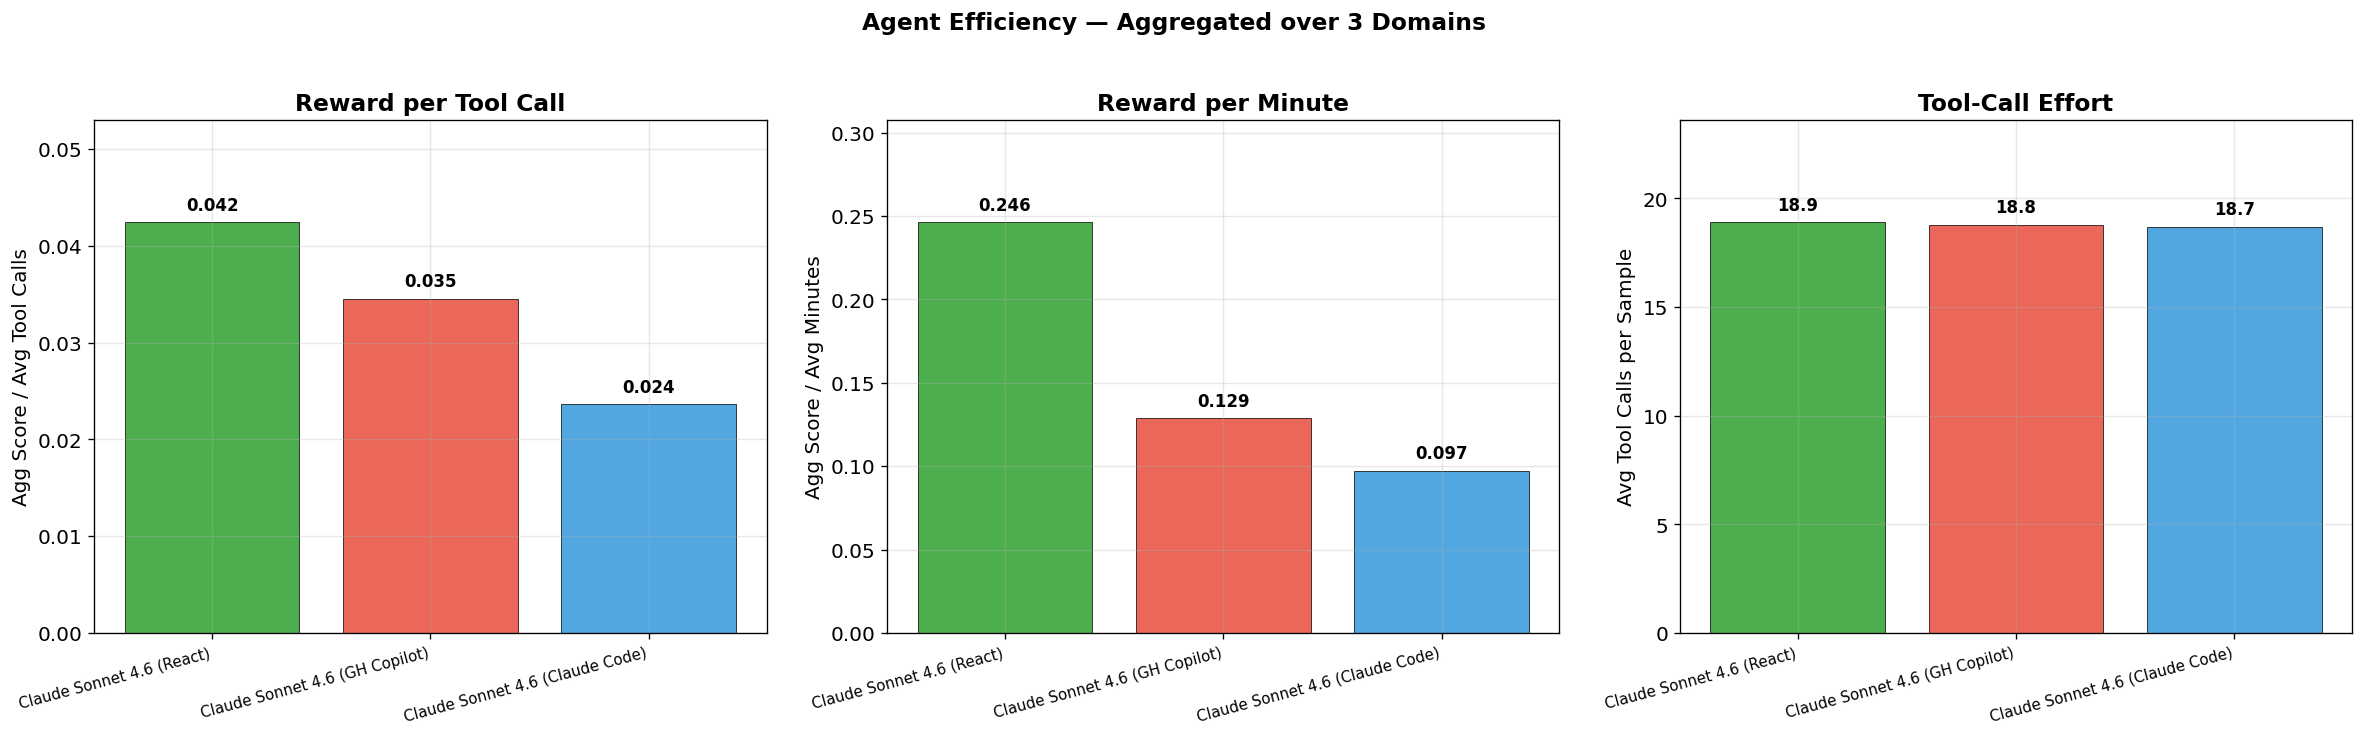

═══ Aggregate Efficiency Summary ═══
Config                               Agg Score  Avg Calls   Avg Time   Rew/Call    Rew/Min
──────────────────────────────────────────────────────────────────────────────────────────
Claude Sonnet 4.6 (React)               0.8011       18.9       3.3m     0.0424     0.2462
Claude Sonnet 4.6 (GH Copilot)          0.6484       18.8       5.0m     0.0345     0.1288
Claude Sonnet 4.6 (Claude Code)         0.4415       18.7       4.5m     0.0236     0.0973


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 6: Agent Trajectory Efficiency
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
x = np.arange(len(CONFIG_ORDER))

# Panel 1: Reward per tool call
ax = axes[0]
rpc_vals = [(agg_scores[c] / agg_tool_calls[c]) if agg_tool_calls[c] > 0 and not np.isnan(agg_tool_calls[c]) else 0
            for c in CONFIG_ORDER]
for i, c in enumerate(CONFIG_ORDER):
    ax.bar(i, rpc_vals[i], color=COLORS.get(c, '#888'), edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, rpc_vals[i] + max(v for v in rpc_vals if v > 0)*0.02, f'{rpc_vals[i]:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(CONFIG_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Agg Score / Avg Tool Calls')
ax.set_title('Reward per Tool Call', fontweight='bold')
ax.set_ylim(0, max(v for v in rpc_vals if v > 0) * 1.25)

# Panel 2: Reward per minute
ax = axes[1]
rpm_vals = [(agg_scores[c] / (agg_time[c] / 60)) if agg_time[c] > 0 and not np.isnan(agg_time[c]) else 0
            for c in CONFIG_ORDER]
for i, c in enumerate(CONFIG_ORDER):
    ax.bar(i, rpm_vals[i], color=COLORS.get(c, '#888'), edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, rpm_vals[i] + max(v for v in rpm_vals if v > 0)*0.02, f'{rpm_vals[i]:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(CONFIG_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Agg Score / Avg Minutes')
ax.set_title('Reward per Minute', fontweight='bold')
ax.set_ylim(0, max(v for v in rpm_vals if v > 0) * 1.25)

# Panel 3: Tool calls per sample
ax = axes[2]
tc_vals = [agg_tool_calls[c] if not np.isnan(agg_tool_calls[c]) else 0 for c in CONFIG_ORDER]
for i, c in enumerate(CONFIG_ORDER):
    ax.bar(i, tc_vals[i], color=COLORS.get(c, '#888'), edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, tc_vals[i] + max(v for v in tc_vals if v > 0)*0.02, f'{tc_vals[i]:.1f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(CONFIG_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Avg Tool Calls per Sample')
ax.set_title('Tool-Call Effort', fontweight='bold')
ax.set_ylim(0, max(v for v in tc_vals if v > 0) * 1.25)

fig.suptitle(f'Agent Efficiency — Aggregated over {len(DOMAINS)} Domains', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'aggregate_agent_efficiency.png', bbox_inches='tight')
plt.show()

print('═══ Aggregate Efficiency Summary ═══')
print(f'{"Config":35s} {"Agg Score":>10s} {"Avg Calls":>10s} {"Avg Time":>10s} {"Rew/Call":>10s} {"Rew/Min":>10s}')
print('─' * 90)
for c, rpc, rpm in zip(CONFIG_ORDER, rpc_vals, rpm_vals):
    print(f'{c:35s} {agg_scores[c]:10.4f} {agg_tool_calls[c]:10.1f} {agg_time[c]/60:9.1f}m {rpc:10.4f} {rpm:10.4f}')

---

## 7. Cross-Domain Ranking Consistency

Do agent architectures rank the same across domains? Bump chart + rank consistency analysis.

**Key findings:**
- **React is perfectly consistent:** Rank 1 in all three domains (mean rank 1.0 ± 0.0). This is the strongest signal in the notebook — React dominates regardless of task type.
- **GH Copilot is volatile:** Ranks 3rd in Excytin and CTI Realm but jumps to 1st (tied with React) on CyBench. Mean rank 2.33 ± 1.15 — the highest standard deviation of any config.
- **Claude Code is moderately consistent** at ranks 2–3 (mean 2.33 ± 0.58), always in the middle-to-bottom tier but never worst on more than one domain.
- The CyBench tie between React and Copilot (both rank 1) is notable — with only 1 sample, this domain is the most volatile discriminator and may shift with additional data.
- **Bottom line:** React is the only architecture that can be relied upon to generalize across all three cybersecurity task domains.

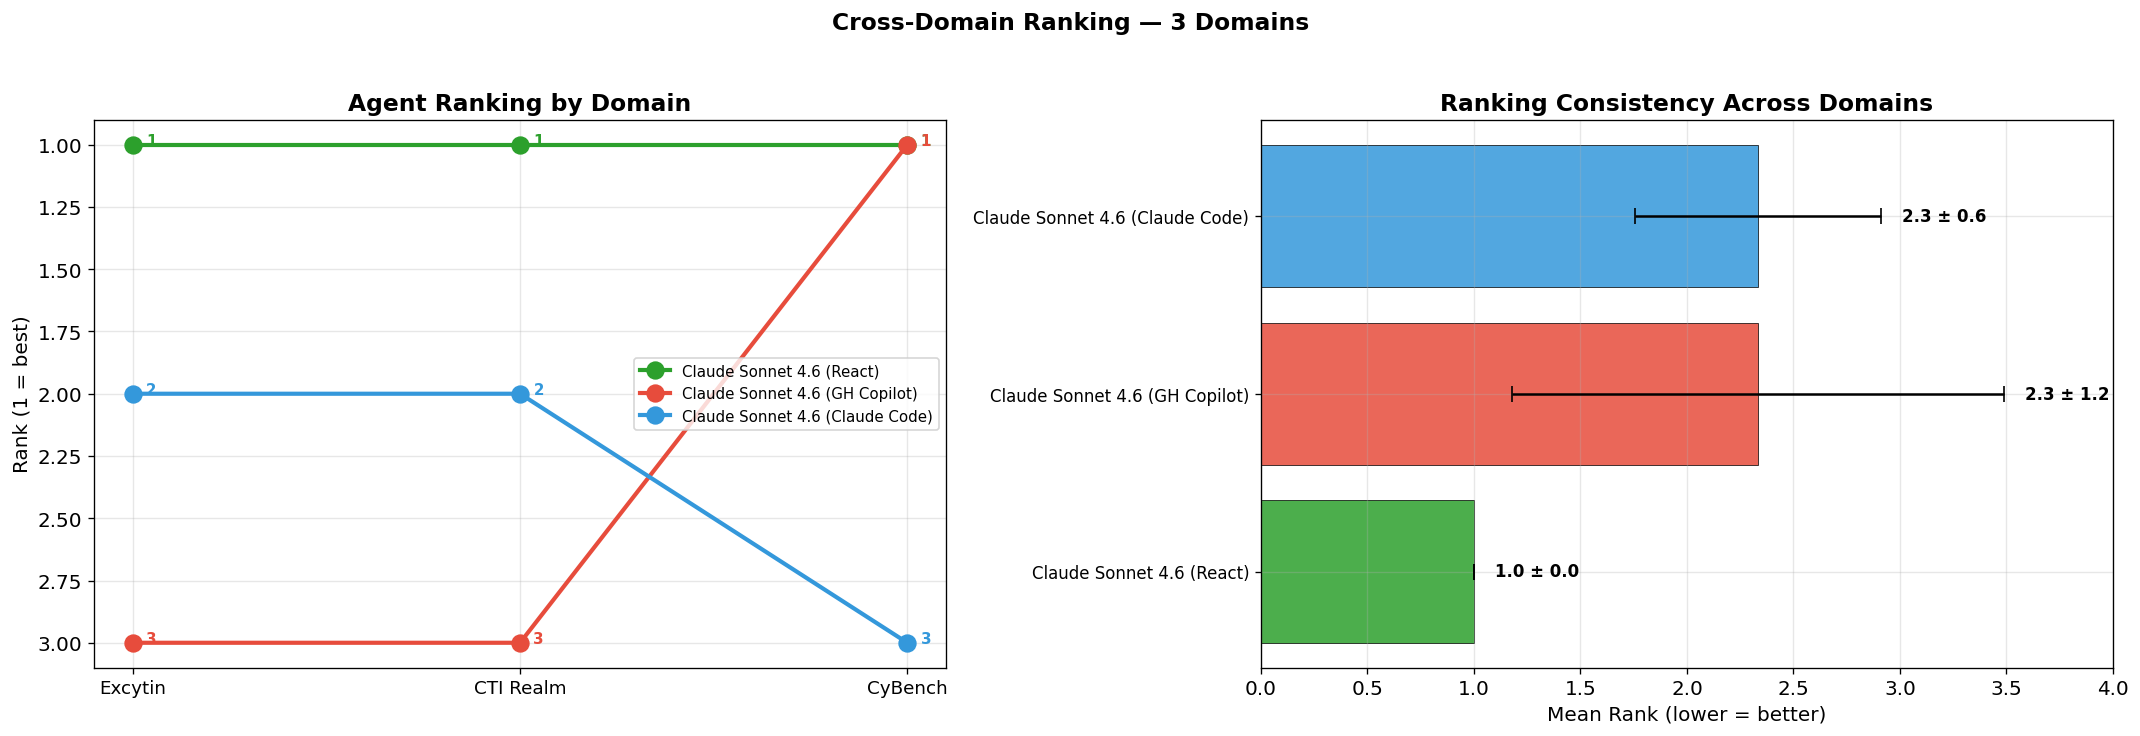

═══ Agent Rankings ═══
                                 Excytin  CTI Realm  CyBench  Mean Rank  Rank Std
Claude Sonnet 4.6 (React)            1.0        1.0      1.0       1.00      0.00
Claude Sonnet 4.6 (GH Copilot)       3.0        3.0      1.0       2.33      1.15
Claude Sonnet 4.6 (Claude Code)      2.0        2.0      3.0       2.33      0.58


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 7: Cross-Domain Ranking Consistency
# ══════════════════════════════════════════════════════════════════════════════
rank_by_domain = pd.DataFrame(index=CONFIG_ORDER, columns=domain_slugs, dtype=float)
for slug in domain_slugs:
    col = score_by_domain[slug].dropna()
    ranks = col.rank(ascending=False, method='min')
    for c in ranks.index:
        rank_by_domain.loc[c, slug] = ranks[c]

rank_display = rank_by_domain.copy()
rank_display.columns = [domain_names[s] for s in domain_slugs]
rank_display['Mean Rank'] = rank_by_domain.mean(axis=1)
rank_display['Rank Std'] = rank_by_domain.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Panel 1: Bump chart
ax = axes[0]
for c in CONFIG_ORDER:
    ranks = [rank_by_domain.loc[c, s] for s in domain_slugs if not np.isnan(rank_by_domain.loc[c, s])]
    valid_domains = [domain_names[s] for s in domain_slugs if not np.isnan(rank_by_domain.loc[c, s])]
    if ranks:
        ax.plot(range(len(ranks)), ranks, marker='o', markersize=10,
                linewidth=2.5, color=COLORS.get(c, '#888'), label=c, zorder=5)
        for xi, r in enumerate(ranks):
            ax.annotate(f'{int(r)}', (xi, r), textcoords='offset points',
                       xytext=(8, 0), fontsize=9, fontweight='bold', color=COLORS.get(c, '#888'))

ax.set_xticks(range(len(domain_slugs)))
ax.set_xticklabels([domain_names[s] for s in domain_slugs], fontsize=11)
ax.set_ylabel('Rank (1 = best)')
ax.set_title('Agent Ranking by Domain', fontweight='bold')
ax.invert_yaxis()
ax.legend(fontsize=9, loc='best')

# Panel 2: Mean rank ± std
ax = axes[1]
mean_ranks = [rank_display.loc[c, 'Mean Rank'] for c in CONFIG_ORDER]
rank_stds = [rank_display.loc[c, 'Rank Std'] if not np.isnan(rank_display.loc[c, 'Rank Std']) else 0
             for c in CONFIG_ORDER]
x = np.arange(len(CONFIG_ORDER))
ax.barh(x, mean_ranks, xerr=rank_stds, color=[COLORS.get(c, '#888') for c in CONFIG_ORDER],
        edgecolor='black', linewidth=0.5, alpha=0.85, capsize=5)
for i, (mr, rs) in enumerate(zip(mean_ranks, rank_stds)):
    ax.text(mr + rs + 0.1, i, f'{mr:.1f} ± {rs:.1f}', va='center', fontsize=10, fontweight='bold')
ax.set_yticks(x)
ax.set_yticklabels(CONFIG_ORDER, fontsize=10)
ax.set_xlabel('Mean Rank (lower = better)')
ax.set_title('Ranking Consistency Across Domains', fontweight='bold')
ax.set_xlim(0, len(CONFIG_ORDER) + 1)

fig.suptitle(f'Cross-Domain Ranking — {len(DOMAINS)} Domains', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'ranking_consistency.png', bbox_inches='tight')
plt.show()

print('═══ Agent Rankings ═══')
print(rank_display.round(2).to_string())

---

## 8. Cross-Domain Performance Radar

Spider chart showing each agent config's normalized performance across domains.

**Key findings:**
- **React (green)** has the largest and most balanced polygon, reaching 0.86 on Excytin, 0.55 on CTI Realm, and 1.0 on CyBench. Its shape is the most "filled out" across all three axes.
- **GH Copilot (red)** shows a dramatic spike on CyBench (1.0) and Excytin (0.79) but collapses on CTI Realm (0.15), creating a highly asymmetric profile.
- **Claude Code (blue)** has the smallest polygon overall — decent on Excytin (0.82) but weak on both CTI Realm (0.17) and CyBench (0.33).
- The radar reveals React's key advantage is **breadth** — it doesn't just win on easy domains but maintains competitive performance on the hardest domain (CTI Realm), which is where the other architectures falter most.

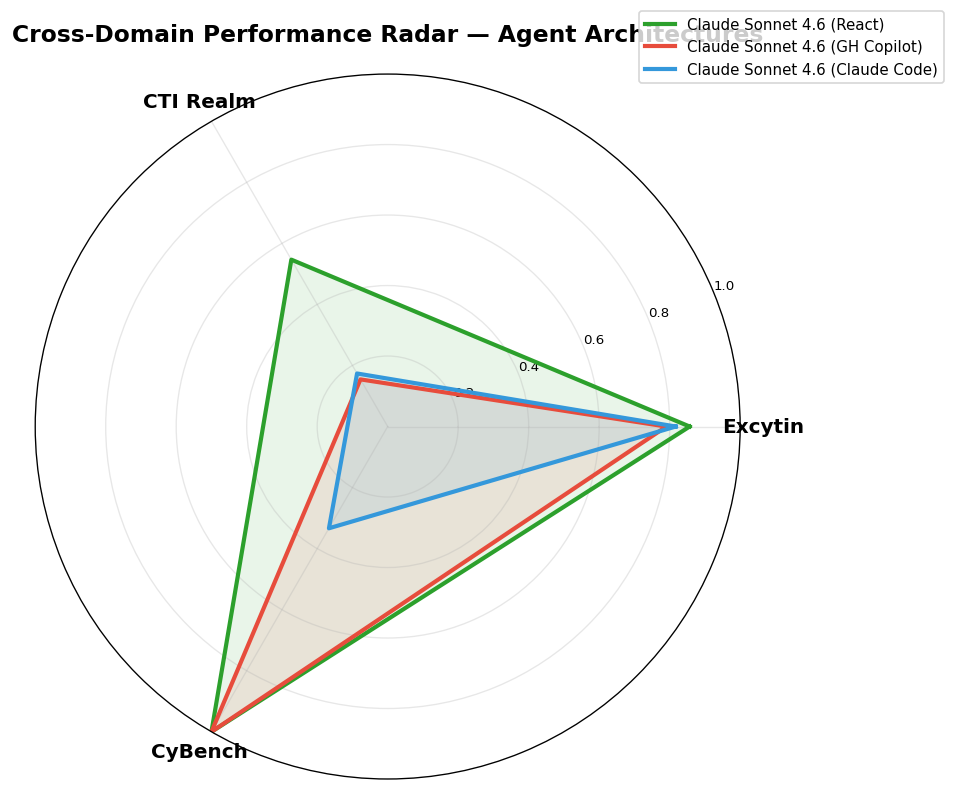

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 8: Cross-Domain Radar Chart
# ══════════════════════════════════════════════════════════════════════════════
n_domains = len(domain_slugs)
angles = np.linspace(0, 2 * np.pi, n_domains, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for c in CONFIG_ORDER:
    values = [score_by_domain.loc[c, s] if not np.isnan(score_by_domain.loc[c, s]) else 0
              for s in domain_slugs]
    values += values[:1]
    ax.plot(angles, values, linewidth=2.5, label=c, color=COLORS.get(c, '#888'))
    ax.fill(angles, values, alpha=0.1, color=COLORS.get(c, '#888'))

ax.set_xticks(angles[:-1])
ax.set_xticklabels([DOMAINS[s]['name'] for s in domain_slugs], fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.set_title(f'Cross-Domain Performance Radar — Agent Architectures',
             fontweight='bold', pad=20, fontsize=14)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'cross_domain_radar.png', bbox_inches='tight')
plt.show()

---

## Summary & Key Takeaways

### Overall Rankings (across 3 domains: Excytin, CTI Realm, CyBench)

| Metric | React | GH Copilot | Claude Code |
|--------|-------|------------|-------------|
| **Aggregate Reward** | **0.801** | 0.648 | 0.441 |
| **Cost / Sample** | **$0.251** | $0.317 | $0.390 |
| **Reward / $** | **3.19** | 2.05 | 1.13 |
| **Reward / Tool Call** | **0.042** | 0.035 | 0.024 |
| **Time / Sample** | **3.3 min** | 5.0 min | 4.5 min |
| **Cross-Domain Rank** | **1.0 ± 0.0** | 2.33 ± 1.15 | 2.33 ± 0.58 |

### Key Conclusions

1. **React dominates every metric.** It achieves the highest score, lowest cost, best efficiency, fastest execution, and perfect ranking consistency. There is no trade-off dimension where another architecture wins.
2. **CTI Realm is the hardest differentiator.** All configs score 0.79+ on Excytin, but CTI Realm scores range from 0.15 to 0.55 — this domain alone drives most of the aggregate separation.
3. **Copilot matches React on final submissions** (0.846 vs 0.852) but lags on intermediate checkpoints (0.380 vs 0.548), suggesting it reaches correct conclusions but doesn't demonstrate thorough investigation.
4. **Claude Code is the least efficient** architecture — highest cost, lowest score, and worst reward-per-dollar. Its Submission score (0.348) is notably poor, indicating difficulty producing valid final answers.
5. **CyBench caveat:** With only 1 sample per config, CyBench results are directional rather than statistically robust. React and Copilot both scored 1.0 while Claude Code scored 0.333.

### Caveats
- Domain weighting is **equal** (each domain contributes 1/3), regardless of sample count. This inflates the impact of CyBench (n=1) relative to Excytin (n=599).
- All configs use **Claude Sonnet 4.6** — performance differences are purely architectural (React loop vs. GH Copilot vs. Claude Code agentic patterns).

### Domain-specific deep dives

- **Excytin:** [`excytin_agent_architecture_analysis.ipynb`](excytin_agent_architecture_analysis.ipynb)
- **CTI Realm:** [`cti_realm_agent_architecture_analysis.ipynb`](cti_realm_agent_architecture_analysis.ipynb)
- **CyBench:** [`cybench_agent_architecture_analysis.ipynb`](cybench_agent_architecture_analysis.ipynb)

### Adding a new domain

1. Create eval logs for each agent × model in the new domain
2. Add an entry to `DOMAINS` in the Configuration cell
3. Re-run the notebook

### Adding a new agent architecture

1. Generate `.eval` files: `uv run inspect eval domains/<domain> --model <model> -T agent=<agent_name>`
2. Add the agent to each domain's `agent_eval_logs` dict
3. Add a color to `AGENT_COLORS`
4. Re-run the notebook